# ACME

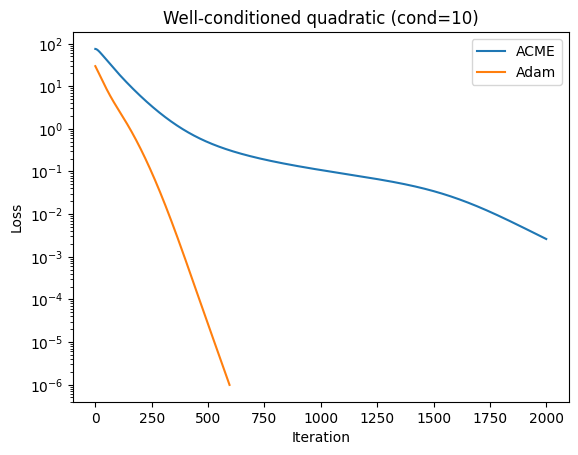

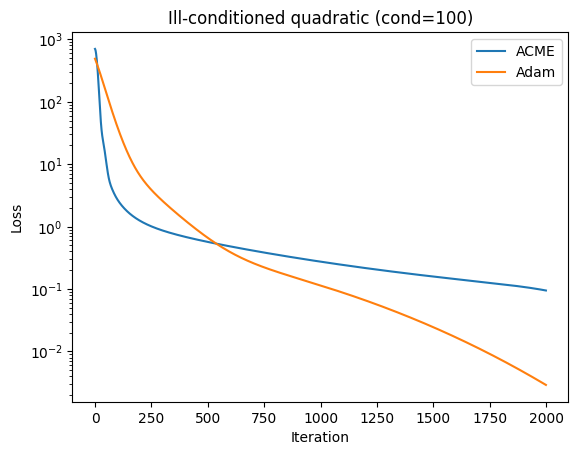

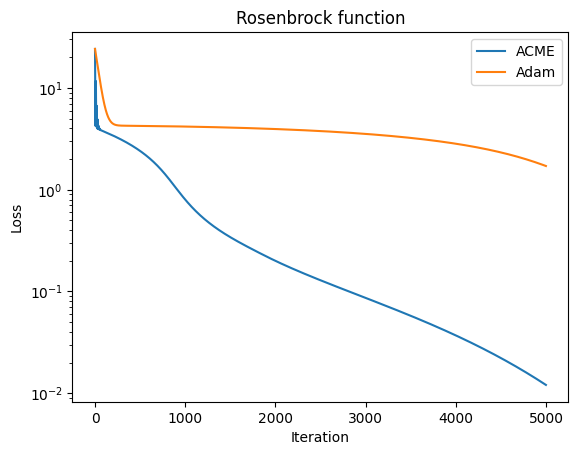

100.0%
100.0%
100.0%
100.0%


ACME - Epoch 1: loss=2.2883, test_acc=0.1234
ACME - Epoch 2: loss=2.1092, test_acc=0.6469
ACME - Epoch 3: loss=1.1922, test_acc=0.8296
ACME - Epoch 4: loss=0.7430, test_acc=0.8568
ACME - Epoch 5: loss=0.5875, test_acc=0.8734
Adam - Epoch 1: loss=0.3438, test_acc=0.9471
Adam - Epoch 2: loss=0.1409, test_acc=0.9606
Adam - Epoch 3: loss=0.0979, test_acc=0.9711
Adam - Epoch 4: loss=0.0742, test_acc=0.9742
Adam - Epoch 5: loss=0.0579, test_acc=0.9775


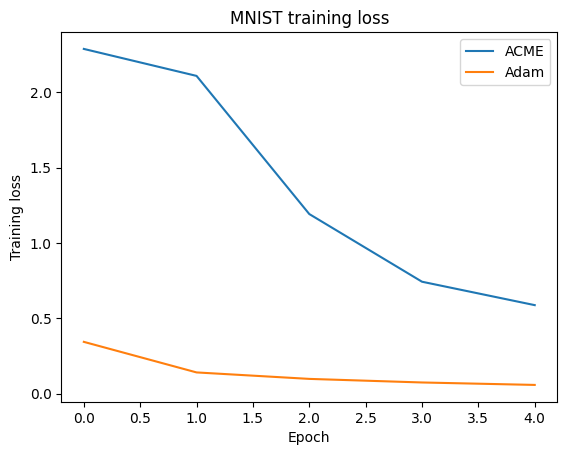

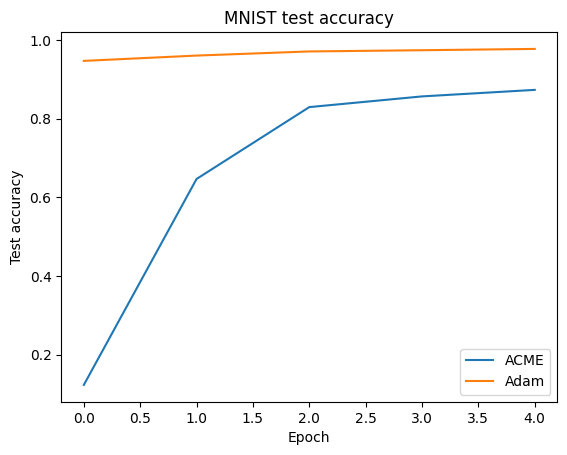

In [1]:
import math
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Optimizer
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

class ACME(Optimizer):
    """
    ACME: Angle- and Curvature-aware Momentum with EMAs
    """

    def __init__(
        self,
        params,
        lr=1e-3,
        betamin=0.7,
        betamax=0.95,
        beta2=0.999,
        rho=0.9999,
        gamma=0.5,
        eta=0.1,
        lambda_r=1.0,
        lambda_d=1.0,
        alpha_sgd=1e-3,
        beta_sgd=0.9,
        kappa_beta=0.99,
        eps=1e-8,
        delta=1e-12,
        delta_c=1e-12,
    ):
        if lr <= 0.0:
            raise ValueError("Invalid learning rate: {}".format(lr))
        if not 0.0 <= betamin <= betamax < 1.0:
            raise ValueError("Invalid betamin/betamax")
        if not 0.0 < beta2 < 1.0:
            raise ValueError("Invalid beta2")
        if not 0.0 < rho < 1.0:
            raise ValueError("Invalid rho")
        defaults = dict(
            lr=lr,
            betamin=betamin,
            betamax=betamax,
            beta2=beta2,
            rho=rho,
            gamma=gamma,
            eta=eta,
            lambda_r=lambda_r,
            lambda_d=lambda_d,
            alpha_sgd=alpha_sgd,
            beta_sgd=beta_sgd,
            kappa_beta=kappa_beta,
            eps=eps,
            delta=delta,
            delta_c=delta_c,
        )
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        """
        Performs a single optimization step.
        """
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            betamin = group["betamin"]
            betamax = group["betamax"]
            beta2 = group["beta2"]
            rho = group["rho"]
            gamma = group["gamma"]
            eta = group["eta"]
            lambda_r = group["lambda_r"]
            lambda_d = group["lambda_d"]
            alpha_sgd = group["alpha_sgd"]
            beta_sgd = group["beta_sgd"]
            kappa_beta = group["kappa_beta"]
            eps = group["eps"]
            delta = group["delta"]
            delta_c = group["delta_c"]

            # global step for this param group
            t = group.get("step", 0) + 1
            group["step"] = t

            # Build flattened gradient for angle & magnitude and kurtosis
            grads = []
            for p in group["params"]:
                if p.grad is None:
                    continue
                grads.append(p.grad.detach().view(-1))
            if len(grads) == 0:
                continue
            g_flat = torch.cat(grads)

            prev_g_flat = group.get("prev_grad_flat", None)

            if prev_g_flat is None:
                c_t = g_flat.new_tensor(1.0)
                d_t = g_flat.new_tensor(1.0)
            else:
                dot = torch.dot(g_flat, prev_g_flat)
                norm_g = torch.norm(g_flat)
                norm_prev = torch.norm(prev_g_flat)
                c_t = dot / (norm_g * norm_prev + delta_c)
                c_t = torch.clamp(c_t, -1.0, 1.0)
                d_t = norm_g / (norm_prev + delta)

            group["prev_grad_flat"] = g_flat.clone()

            # magnitude damping
            q_t = 1.0 / (1.0 + lambda_d * torch.abs(d_t - 1.0))
            a_t = torch.clamp(c_t, min=0.0)
            phi_t = a_t * q_t
            phi_t = torch.clamp(phi_t, 0.0, 1.0)
            beta_t = betamin + (betamax - betamin) * phi_t
            beta_t = beta_t.item()

            # kurtosis EMAs (group-level)
            E2 = group.get("E2", torch.zeros(1, device=g_flat.device))
            E4 = group.get("E4", torch.zeros(1, device=g_flat.device))
            g2_mean = g_flat.pow(2).mean()
            g4_mean = g_flat.pow(4).mean()
            E2 = kappa_beta * E2 + (1.0 - kappa_beta) * g2_mean
            E4 = kappa_beta * E4 + (1.0 - kappa_beta) * g4_mean
            group["E2"] = E2
            group["E4"] = E4
            kurt = E4 / (E2.pow(2) + delta)
            k_excess = torch.clamp(kurt - 3.0, min=0.0)
            h_scalar = 1.0 / (1.0 + eta * k_excess)
            h_scalar = h_scalar.item()

            # bias correction factors for v and u
            bias_correction2 = 1.0 - beta2 ** t
            bias_correctionu = 1.0 - rho ** t

            # bias correction for m using cumulative product B
            B = group.get("B", 1.0)
            B = B * beta_t
            group["B"] = B
            denom_m = 1.0 - B + 1e-16

            for p in group["params"]:
                if p.grad is None:
                    continue
                grad = p.grad

                state = self.state[p]
                if len(state) == 0:
                    state["m"] = torch.zeros_like(p.data)
                    state["v"] = torch.zeros_like(p.data)
                    state["u"] = torch.zeros_like(p.data)
                    state["z"] = torch.zeros_like(p.data)

                m = state["m"]
                v = state["v"]
                u = state["u"]
                z = state["z"]

                # first moment
                m.mul_(beta_t).add_(grad, alpha=(1.0 - beta_t))

                # second moments
                v.mul_(beta2).addcmul_(grad, grad, value=(1.0 - beta2))
                u.mul_(rho).addcmul_(grad, grad, value=(1.0 - rho))

                # SGD-like momentum
                z.mul_(beta_sgd).add_(grad, alpha=(1.0 - beta_sgd))

                # bias correction
                m_hat = m / denom_m
                v_hat = v / bias_correction2
                u_hat = u / bias_correctionu

                # curvature ratio
                r = (v_hat + delta) / (u_hat + delta)
                # curvature-based adaptivity
                a_curv = torch.pow(r, -gamma)
                # heavy-tail damping
                h = h_scalar

                s_total = a_curv * h
                alpha_adapt = lr * s_total

                adapt_step = alpha_adapt * m_hat / (torch.sqrt(u_hat) + eps)

                # curvature stability and blending
                s_stab = torch.exp(-lambda_r * torch.abs(torch.log(r + 1e-16)))
                w = 1.0 - s_stab

                sgd_step = alpha_sgd * z

                step_tensor = w * adapt_step + (1.0 - w) * sgd_step

                p.data.add_(-step_tensor)

        return loss


# -----------------------
# Quadratic experiments
# -----------------------

def make_spd_matrix(dim, cond_number):
    """
    Make a symmetric positive definite matrix with given condition number.
    """
    A = np.random.randn(dim, dim)
    Q, _ = np.linalg.qr(A)
    eigs = np.linspace(1.0, cond_number, dim)
    D = np.diag(eigs)
    M = Q @ D @ Q.T
    M = 0.5 * (M + M.T)
    return M

def run_quadratic(cond_number, dim=20, max_iters=2000, tol=1e-6, lr=1e-2):
    Q_np = make_spd_matrix(dim, cond_number)
    Q = torch.from_numpy(Q_np).float().to(device)

    def loss_fn(x):
        return 0.5 * (x.unsqueeze(0) @ Q @ x.unsqueeze(1)).squeeze()

    results = {}

    for name, opt_class, opt_kwargs in [
        ("ACME", ACME, {"lr": lr}),
        ("Adam", torch.optim.Adam, {"lr": lr}),
    ]:
        x = torch.randn(dim, device=device, requires_grad=True)
        optimizer = opt_class([x], **opt_kwargs)
        losses = []
        for it in range(1, max_iters + 1):
            optimizer.zero_grad()
            loss = loss_fn(x)
            losses.append(loss.item())
            if loss.item() < tol:
                break
            loss.backward()
            optimizer.step()
        results[name] = np.array(losses)
    return results

# -----------------------
# Rosenbrock experiment
# -----------------------

def rosenbrock(x, y):
    return (1 - x) ** 2 + 100 * (y - x ** 2) ** 2

def run_rosenbrock(max_iters=5000, tol=1e-4, lr=1e-3):
    results = {}
    start = torch.tensor([-1.2, 1.0], device=device)

    for name, opt_class, opt_kwargs in [
        ("ACME", ACME, {"lr": lr}),
        ("Adam", torch.optim.Adam, {"lr": lr}),
    ]:
        params = nn.Parameter(start.clone())
        optimizer = opt_class([params], **opt_kwargs)
        losses = []
        for it in range(1, max_iters + 1):
            optimizer.zero_grad()
            x, y = params[0], params[1]
            loss = rosenbrock(x, y)
            losses.append(loss.item())
            if loss.item() < tol:
                break
            loss.backward()
            optimizer.step()
        results[name] = np.array(losses)
    return results

# -----------------------
# MNIST experiment
# -----------------------

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

def get_mnist_loaders(batch_size=64):
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    train_dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
    test_dataset = datasets.MNIST(root="./data", train=False, transform=transform, download=True)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    return train_loader, test_loader

def train_epoch(model, optimizer, loader, device):
    model.train()
    total_loss = 0.0
    total_samples = 0
    for data, target in loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.size(0)
        total_samples += data.size(0)
    return total_loss / total_samples

def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            pred = output.argmax(dim=1)
            correct += (pred == target).sum().item()
            total += data.size(0)
    return correct / total

def run_mnist(epochs=5, lr=1e-3, batch_size=64):
    """
    For your project, set epochs=20 (spec requirement).
    Kept 5 here so it's quicker to run while testing.
    """
    train_loader, test_loader = get_mnist_loaders(batch_size=batch_size)
    results = {}

    for name, opt_class, opt_kwargs in [
        ("ACME", ACME, {"lr": lr}),
        ("Adam", torch.optim.Adam, {"lr": lr}),
    ]:
        model = SimpleNet().to(device)
        optimizer = opt_class(model.parameters(), **opt_kwargs)
        train_losses = []
        test_accuracies = []
        for epoch in range(1, epochs + 1):
            train_loss = train_epoch(model, optimizer, train_loader, device)
            test_acc = evaluate(model, test_loader, device)
            train_losses.append(train_loss)
            test_accuracies.append(test_acc)
            print(f"{name} - Epoch {epoch}: loss={train_loss:.4f}, test_acc={test_acc:.4f}")
        results[name] = {
            "train_losses": np.array(train_losses),
            "test_accuracies": np.array(test_accuracies),
        }
    return results

# -----------------------
# Main: run and plot
# -----------------------

def main():
    # Quadratic: well-conditioned (cond <= 10)
    quad_well = run_quadratic(cond_number=10, dim=20, lr=1e-2)
    # Quadratic: ill-conditioned (cond >= 50)
    quad_ill = run_quadratic(cond_number=100, dim=20, lr=1e-2)

    plt.figure()
    for name, losses in quad_well.items():
        plt.plot(losses, label=name)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Well-conditioned quadratic (cond=10)")
    plt.legend()
    plt.show()

    plt.figure()
    for name, losses in quad_ill.items():
        plt.plot(losses, label=name)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Ill-conditioned quadratic (cond=100)")
    plt.legend()
    plt.show()

    # Rosenbrock
    ros_results = run_rosenbrock(lr=1e-3)
    plt.figure()
    for name, losses in ros_results.items():
        plt.plot(losses, label=name)
    plt.yscale("log")
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title("Rosenbrock function")
    plt.legend()
    plt.show()

    # MNIST (set epochs=20 for final project)
    mnist_results = run_mnist(epochs=5, lr=1e-3, batch_size=64)
    plt.figure()
    for name, res in mnist_results.items():
        plt.plot(res["train_losses"], label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Training loss")
    plt.title("MNIST training loss")
    plt.legend()
    plt.show()

    plt.figure()
    for name, res in mnist_results.items():
        plt.plot(res["test_accuracies"], label=name)
    plt.xlabel("Epoch")
    plt.ylabel("Test accuracy")
    plt.title("MNIST test accuracy")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()